In [2]:
# Standard libraries
import os
import itertools
from collections import Counter
import math
import json
import copy
import warnings

# EEG & Signal Processing
import mne 
mne.set_log_level('ERROR') # Only print errors from MNE, nothing else
warnings.filterwarnings("ignore", category=RuntimeWarning) # Ignore global RunTimeWarnings

from mne.preprocessing import ICA
from mne_connectivity import spectral_connectivity_epochs, envelope_correlation
from mne.time_frequency import stft, psd_array_welch
from scipy.stats import differential_entropy
from scipy.signal import butter, filtfilt, hilbert
from asrpy import ASR

# SVR
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# Data manip
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
import scipy.io as sio

# Graph
import networkx as nx

# Torch geometric
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv
from torch_geometric.utils import dropout_edge
from torch_geometric.nn.norm import BatchNorm
from torch_geometric.nn import global_mean_pool, global_add_pool, global_max_pool
from torch_geometric.explain import Explainer, GNNExplainer

# Torch
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

/Users/jasonlee/Desktop/code_stuff/graph/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Collecting all files with specific ext
def find_files(data_path, ext):
    found_files = []
    for root, _, files in os.walk(data_path):
        for file in files:
            if file.endswith(ext):
                full_path = os.path.join(root, file)
                found_files.append(full_path)
                
    return found_files

# EEGGraphBuilder Class

In order to setup the "experiment" by testing different functional connectivity measures, edge threshold amounts, and node features, I created a class called EEGGraphBuilder that turns a file path (e.g. a patient's eeg) into graph data objects. I needed a one stop shop that has all these methods to keep everything in one central EEG + Graph data hub.

In [6]:
class EEGGraphBuilder:
    """
    A pipeline for transforming raw EEG signals into graph objects.

    This class handles the end-to-end process of loading EEG data, cleaning, epoching, and extracting node and edge 
    features for Graph Neural Networks (GNN).

    Attributes:
        raw (mne.io.Raw): The underlying MNE Raw object.
        epochs (mne.Epochs): The epoched EEG data after preprocessing.
        sfreq (float): Sampling frequency of the data.
    """
    
    def __init__(
        self,
        file_path,
        clean=False,
        sfreq=None,
        epoch_length=30.0,
        epoch_overlap=15.0,
        fmin=0.5,
        fmax=45,
        edge_threshold=75,
        fc_method='plv',
        node_feature='stft',
        node_drop=None
    ):
        """
        Initializes the builder and loads the EEG data.

        Args:
            file_path (str): Path to the .set (EEGLAB) file.
            clean (bool): If True, applies ASR and ICA cleaning during init.
            sfreq (float, optional): Override for the sampling frequency.
            epoch_length (float): Duration of each epoch in seconds.
            epoch_overlap (float): Overlap between epochs in seconds.
            fmin (float): Minimum frequency for filtering and feature extraction.
            fmax (float): Maximum frequency for filtering and feature extraction.
            edge_threshold (int): Percentile (0-100) used to sparsify the graph edges.
            fc_method (str): Functional connectivity metric ('plv', 'aec', 'corr', etc.).
            node_feature (str): Type of node features ('stft', 'hjorth', 'psd', 'de').
            node_drop (list of str, optional): List of channel names to exclude.
        """
        
        self.file_path = file_path
        self.clean = clean
        self.epoch_length = epoch_length
        self.epoch_overlap = epoch_overlap
        self.fc_method = fc_method
        self.fmin = fmin
        self.fmax = fmax
        self.edge_threshold = edge_threshold
        self.node_feature = node_feature
        self.node_drop = node_drop

        # Placeholders until initialized
        self.raw = None
        self.epochs = None
        self.node_features = None
        self.edge_features = None
        self.edge_index = None


        # Raw file and sampling freq
        raw_load = mne.io.read_raw_eeglab(self.file_path, preload=True)
        
        # Cleaning EEG
        if self.clean is True:
            self.raw = self.clean_eeg(raw_load)
        else:
            self.raw = raw_load
            
        self.sfreq = self.raw.info['sfreq']
        
        # Dropping channels
        if self.node_drop is not None:
            self.raw.drop_channels(self.node_drop)
        
        
    def clean_eeg(self, raw, l_freq=0.5, h_freq=45, asr_sd=17, n_components=None, 
              method='fastica', random_state=99, extreme_thresh=2.0, 
              percent_threshold=10):
        """
        Cleans signal using Artifact Subspace Retrieval (ASR) and Independent Component Analysis (ICA).
        
        Identifies and removes 'extreme' ICA components based on a Z-score threshold 
        of signal activity.
        """

        # Filter and create copy
        raw_for_fit = raw.copy().filter(l_freq=l_freq, h_freq=h_freq, method='fir', verbose=False)

        # Artifact Subspace Retrieval 
        asr_obj = ASR(sfreq=raw.info['sfreq'], cutoff=asr_sd) 
        asr_obj.fit(raw_for_fit)
        raw_for_fit = asr_obj.transform(raw_for_fit)
            
        # ICA fitting
        ica = ICA(n_components=n_components, method=method, random_state=random_state)
        ica.fit(raw_for_fit, verbose=False)

        # Extreme signal activity
        sources = ica.get_sources(raw_for_fit).get_data()  # shape: n_components x n_times
        z_sources = np.abs((sources - sources.mean(axis=1, keepdims=True)) / sources.std(axis=1, keepdims=True))

        # Calculate exceeds threshold
        percent_extreme = np.mean(z_sources > extreme_thresh, axis=1) * 100

        # Identify components where the "extreme" percentage is too high
        reject_components = [i for i, perc in enumerate(percent_extreme) if perc >= percent_threshold]
        ica.exclude = reject_components

        # Create final clean object
        raw_clean = ica.apply(raw_for_fit.copy())

        return raw_clean
        
    def create_epoch(self):
        # shape (n_epochs, n_chan, n_times)
        self.epochs = mne.make_fixed_length_epochs(self.raw, duration=self.epoch_length, overlap=self.epoch_overlap, preload=True) 
        self.n_epochs = len(self.epochs) # store n epochs as attribute to method
        
        return self.epochs
    
    def compute_node_features(self, epoch_idx):
        """
        Extracts features for each electrode (node) for a specific epoch.

        Returns:
            np.ndarray: Matrix of shape (n_channels, n_features).
        """
        if self.node_feature == 'stft':
            return self._compute_node_features_stft(epoch_idx)
        
        elif self.node_feature == 'hjorth':
            return self._compute_node_features_hjorth(epoch_idx)
        
        elif self.node_feature == 'psd':
            return self._compute_node_features_psd(epoch_idx)
        
        elif self.node_feature == 'de':
            return self._compute_node_features_de(epoch_idx)
        
        else:
            print("Pick either: stft, hjorth, psd, or de")
        
    def _compute_node_features_stft(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx] 
        wsize = 256
        tstep = 128
    
        # Compute stft and take the abs (magnitude)
        stft_data = stft(data, wsize=wsize, tstep=tstep)
        stft_mag = np.abs(stft_data) # shape (n_chan, n_filter_freq, n_time_steps)

        # Frequency mask
        freqs = np.fft.rfftfreq(wsize, d=1.0/self.sfreq)
        freq_mask = (freqs >= self.fmin) & (freqs <= self.fmax) # Adjust min/max to focus on certain freq bands
        
        # Average over time
        node_features = stft_mag[:, freq_mask, :].mean(axis=2)
        
        return node_features # (n_chan, n_freq_bins)
    
    def _compute_node_features_hjorth(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx]
        
        # 3 Hjorth parameters
        activity = np.var(data, axis=1)
        mobility = np.sqrt(
            np.var(np.diff(data, axis=1), axis=1) / activity
        )
        complexity = (
            np.sqrt(
                np.var(np.diff(np.diff(data, axis=1), axis=1), axis=1)
                / np.var(np.diff(data, axis=1), axis=1)
            ) / mobility
        )

        return np.stack([activity, mobility, complexity], axis=1)
        
    def _compute_node_features_psd(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx]        
        psd, freq = psd_array_welch(data, self.sfreq, self.fmin, self.fmax) # Adjust min/max to focus on certain freq bands
        
        return psd # (n_chan, nfreq)
        
    def _bandpass(self, data, low, high, order=4):
        nyq = 0.5 * self.sfreq
        b, a = butter(order, [low/nyq, high/nyq], btype='band')
        return filtfilt(b, a, data)

    def _compute_node_features_de(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx]

        # Canonical freq band range
        bands = {
            "delta": (0.5, 4),
            "theta": (4, 8),
            "alpha": (8, 13),
            "beta":  (13, 30),
            "gamma": (30, 45)
        }

        de_features = []

        for low, high in bands.values():
            band_de = []
            for chan in data:
                band_signal = self._bandpass(chan, low, high)
                var = np.var(band_signal)
                de = 0.5 * np.log(2 * np.pi * np.e * var + 1e-8)
                band_de.append(de)
            de_features.append(band_de)

        return np.array(de_features).T # (n_chan, n_bands)
    
    def compute_edge_features(self, epoch_idx):
        # FC measures using spectral_connectivity_epochs method
        mne_fc_methods = ['coh', 'pli', 'wpli', 'gc', 'imcoh']

        if self.fc_method.lower() in mne_fc_methods:
            # Slice 1 epoch
            epoch_slice = self.epochs[epoch_idx:epoch_idx + 1]

            conn = spectral_connectivity_epochs(
                epoch_slice,
                method=self.fc_method,
                fmin=self.fmin,
                fmax=self.fmax,
                faverage=True,
                verbose=False
            )

            # Dense FC matrix (n_channels, n_channels)
            fc_matrix = conn.get_data(output="dense")[:, :, 0]

            return self._compute_edge_features_threshold(fc_matrix)

        elif self.fc_method == 'plv':
            return self._compute_edge_features_plv_time(epoch_idx)
        
        elif self.fc_method == 'aec':
            return self._compute_edge_features_aec(epoch_idx)
        
        elif self.fc_method == 'corr':
            return self._compute_edge_features_corr(epoch_idx)
    
    def compute_edge_brain_region(self, adj_list):
        # Inputs a list of tuple (i,j) relationship
        # Ex. [ (Fp1, Fp2), (O1,O2) ]
        n_chan = len(self.raw.ch_names)
        fc_matrix = np.zeros((n_chan,n_chan))
        
        # Create a mapping dictionary for quick lookup
        ch_map = {name: i for i, name in enumerate(self.raw.ch_names)}
        
        for ch_a, ch_b in adj_list:
            if ch_a in ch_map and ch_b in ch_map:
                i, j = ch_map[ch_a], ch_map[ch_b]
                fc_matrix[i, j] = 1.0
                fc_matrix[j, i] = 1.0
            else:
                print(f"Warning: Channels {ch_a} or {ch_b} not found in data.")
     
        # PyG input
        mask = fc_matrix > 0 
        edge_index = np.array(np.where(mask))
        edge_attr = fc_matrix[mask][:, None]  
        
        return fc_matrix, edge_index, edge_attr
    
    def _compute_edge_features_threshold(self, fc_matrix):
        """
        Applies percentile thresholding to a connectivity matrix.

        Args:
            fc_matrix (np.ndarray): Symmetrical adjacency matrix.

        Returns:
            tuple: (dense_matrix, edge_index, edge_attr) formatted for PyTorch Geometric.
        """
        # Remove self loops
        np.fill_diagonal(fc_matrix, 0)

        # Thresholding
        thresh = np.percentile(fc_matrix, self.edge_threshold)
        mask = fc_matrix >= thresh

        # PyG inputs
        edge_index = np.array(np.where(mask))           
        edge_attr = fc_matrix[mask][:, None]        

        return fc_matrix, edge_index, edge_attr

    def _compute_edge_features_aec(self, epoch_idx):
        epoch_slice = self.epochs[epoch_idx:epoch_idx + 1]

        # Compute envelope corr
        corr_obj = envelope_correlation(epoch_slice, orthogonalize='pairwise', absolute=True)
        fc_matrix = corr_obj.combine().get_data(output='dense')[:, :, 0] # (n_chan, n_chan)
        
        return self._compute_edge_features_threshold(fc_matrix)
        
    def _compute_edge_features_corr(self, epoch_idx):
        data = self.epochs.get_data()[epoch_idx]
        fc_matrix = np.corrcoef(data)  # shape: (n_channels, n_channels)

        return self._compute_edge_features_threshold(fc_matrix)

    def _compute_edge_features_plv_time(self, epoch_idx):
        data = self.epochs.get_data(copy=False)[epoch_idx]
        n_chan, n_times = data.shape

        # Frequency bands of interest
        filtered_data = np.array([self._bandpass(chan, self.fmin, self.fmax) for chan in data])

        # Hilbert transform
        analytic_signal = hilbert(filtered_data, axis=1)
        phase = np.angle(analytic_signal)
        complex_phase = np.exp(1j * phase)

        fc_matrix = np.abs(complex_phase @ complex_phase.conj().T) / n_times

        return self._compute_edge_features_threshold(fc_matrix)

# EEGGraphNode

Class used to test out the support vector regression (SVR) and CNN baseline models that take in node strength and weighted adjacency matrix respectively. SVR-NS (node strength) uses the node_strength method; SVR-AM (adjacency matrix) and CNN uses the adjacency matrix, however SVR-AM uses the flattened diagonal version of the matrix while CNN uses the full 19x19 matrix.

In [7]:
class EEGGraphNode(EEGGraphBuilder):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
    def node_strength(self, epoch_idx, npy_array=True):
        # Edge features
        fc_matrix, edge_index, edge_attr = self.compute_edge_features(epoch_idx)
        
        # Calculate node strength 
        G = nx.from_numpy_array(fc_matrix)
        node_strength = G.degree(weight='weight')
        
        if npy_array:
            node_strength = np.array([weight for node, weight in node_strength])

        return node_strength
    
    def node_vec_adj(self, epoch_idx, flatten=True):
        # Edge features
        adj, edge_index, edge_attr = self.compute_edge_features(epoch_idx)

        if flatten:
            row_idx, col_idx = np.triu_indices_from(adj, k=1) # Upper diag indices ignoring diag
            adj = adj[row_idx, col_idx]

        return adj

# PyG Data class

Pytorch Geometric (PyG) is the main deep learning library I'll be using to build my models and so I need to turn my Numpy matrices (output of the EEGGraphBuilder) into PyG data objects.

In [8]:
class EEGGraphPyG(EEGGraphBuilder):
    """
    A PyTorch Geometric (PyG) class using the EEGGraphBuilder.

    This subclass extends the base builder to convert processed EEG epochs 
    directly into `torch_geometric.data.Data` objects, which are used for 
    training Graph Neural Networks.

    Inherits all preprocessing and feature extraction logic from EEGGraphBuilder.
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        
    def pyg_data(self, epoch_idx):
        """
        Generates a PyG Data object for a specific EEG epoch.

        This method computes node feature and functional connectivity, 
        then casts the NumPy arrays into Torch tensors.

        Args:
            epoch_idx (int): The index of the epoch to process.

        Returns:
            torch_geometric.data.Data: A data object containing:
                - x (Tensor): Node feature matrix [n_nodes, n_node_features].
                - edge_index (Tensor): Graph connectivity in COO format [2, n_edges].
                - edge_attr (Tensor): Edge weights/features [n_edges, 1].
                - node_names (list): List of channel names corresponding to nodes.
        """
        node_features = self.compute_node_features(epoch_idx)  # np array (n_nodes, n_node_features)
        x = torch.tensor(node_features, dtype=torch.float)

        # Edge features
        fc_matrix, edge_index, edge_attr = self.compute_edge_features(epoch_idx)
        edge_index = torch.tensor(edge_index, dtype=torch.long)
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

        # Naming PyG nodes
        chan_names = self.raw.ch_names
        
        # Return PyG data object
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)        
        data.node_names = chan_names
        
        return data

# Visualize Graphs

I included a class and some code below to visualize the data to (1) make sure my classes above work (2) include the images in my research paper.

In [12]:
class EEGGraphPlot():
    """
    Visualization for EEG functional connectivity graphs.

    Attributes:
        builder (EEGGraphBuilder): An instance of the builder containing 
            the raw EEG info and channel montage.
    """
    def __init__(self, eeg_builder_obj):
        self.builder = eeg_builder_obj
        
    def plot(self, adj_matrix, title='Graph'):
        """
        Visualizes a 2D graph representation of node connectivity.

        This method extracts 3D electrode coordinates from the MNE montage, 
        projects them to 2D, and uses NetworkX to draw nodes and weighted 
        edges based on the input adjacency matrix.

        Args:
            adj_matrix (np.ndarray): A square (n_channels x n_channels) 
                connectivity matrix (e.g., PLV, Correlation).
            title (str, optional): The title for the Matplotlib figure. 
                Defaults to 'Graph'.
        """
        
        node_labels = self.builder.raw.ch_names
        
        # Montage info
        montage = self.builder.raw.get_montage()
        pos_3d = montage.get_positions()['ch_pos']
        pos = {ch: pos_3d[ch][:2] for ch in node_labels} # from 3d to 2d format
        
        # Build Networkx Graph
        G = nx.from_numpy_array(adj_matrix)
        label_mapping = {i: ch for i, ch in enumerate(node_labels)} # Labeling nodes
        G = nx.relabel_nodes(G, label_mapping) 
        
        # Plot Shape
        plt.figure(figsize=(10, 8))
        plt.title(title)
        
        # Draw nodes based on montage position
        nx.draw_networkx_nodes(G, pos, node_size=500, node_color='lightblue')
        nx.draw_networkx_labels(G, pos, font_size=8)
        
        # Draw variable edge width based on fc weight
        edges, weights = zip(*nx.get_edge_attributes(G,'weight').items()) 
        nx.draw_networkx_edges(G, pos, edgelist=edges, width=np.array(weights)*1.5)

        plt.show()

## Visualize fixed brain graph

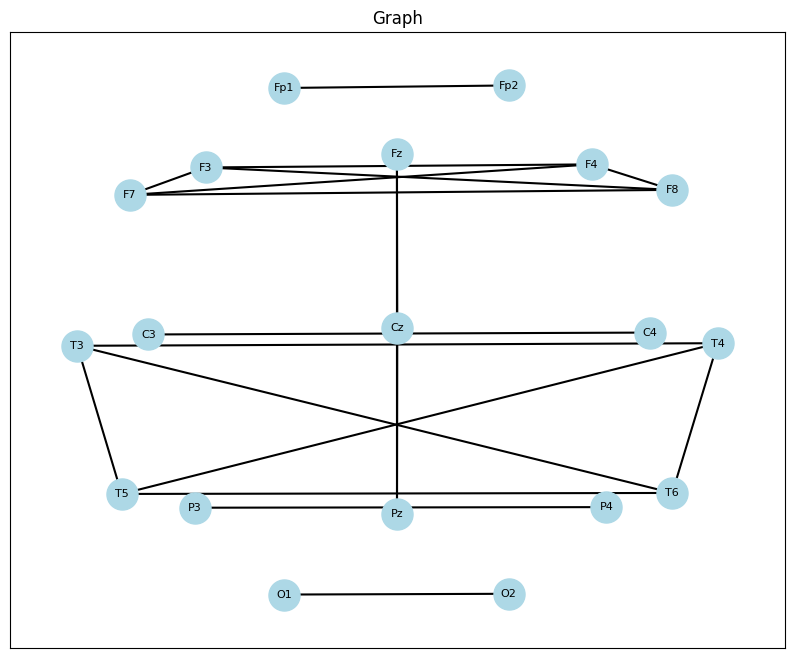

In [13]:
# Load data
file_path = 'dataset/openneuro - AD/regular/sub-005_task-eyesclosed_eeg.set'
eeg_obj = EEGGraphBuilder(file_path)
eeg_obj.create_epoch()

# Generate matrix
adj_list = [
            ('Fp1', 'Fp2'), 
            ('O1', 'O2'),   
            ('Fz', 'Cz'), ('Fz', 'Pz'), ('Cz', 'Pz'),
            ('F7', 'F3'), ('F7', 'F4'), ('F7', 'F8'), ('F3', 'F4'), ('F3', 'F8'), ('F4', 'F8'),
            ('C3', 'C4'), 
            ('T3', 'T5'), ('T3', 'T4'), ('T3', 'T6'), ('T4', 'T6'), ('T5', 'T6'), ('T4', 'T5'),
            ('P3', 'P4')
            ]
fc_matrix, _, _ = eeg_obj.compute_edge_brain_region(adj_list)

# Pass the eeg_obj to the plotter
plotter = EEGGraphPlot(eeg_obj)
plotter.plot(fc_matrix)

# FC brain graph w/ drop nodes

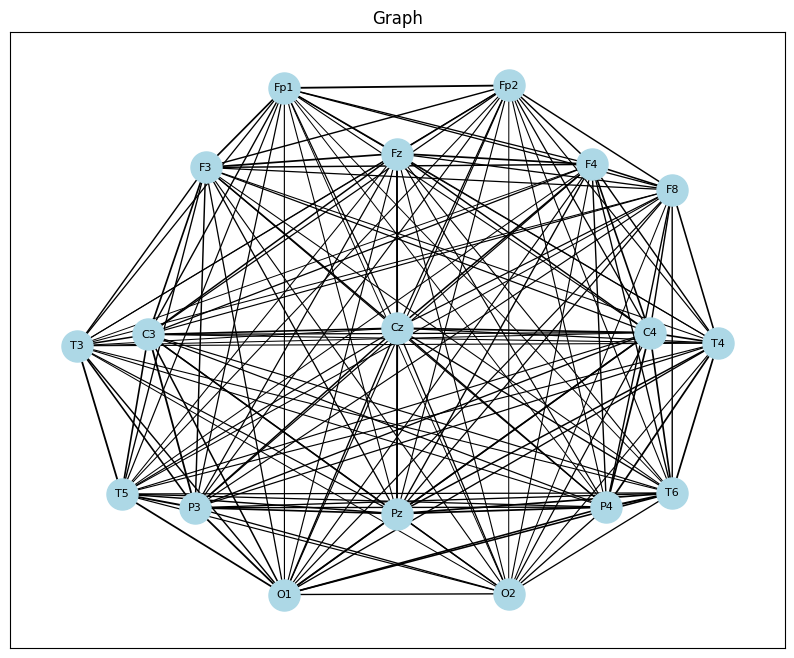

In [14]:
# Load data
file_path = 'dataset/openneuro - AD/regular/sub-030_task-eyesclosed_eeg.set'
eeg_obj = EEGGraphBuilder(file_path, fc_method='plv', edge_threshold=99, node_drop=['F7'])
eeg_obj.create_epoch()

# Plot
fc_matrix, _, _ = eeg_obj.compute_edge_features(epoch_idx=0)
plotter = EEGGraphPlot(eeg_obj)
plotter.plot(fc_matrix)

# Patients EEG -> EEGGraphBuilder -> Dataloader

This is the "data engineering" side of the project, if you will. The below class is a way to create iterable objects depending on what I need. For GNN model I need a list of PyG data objects and for my baseline models - SVR & CNN - I need numpy arrays and tensors respectively.

In [9]:
class EEGDatasetBuilder:
    def __init__(self, eeg_files, patient_tsv, ad_pd='ad', exclude=None, **eeg_kwargs):
        self.eeg_files = eeg_files
        self.ad_pd = ad_pd
        self.eeg_kwargs = eeg_kwargs
        
        # Load and filter the dataframe 
        self.df = pd.read_csv(patient_tsv, sep='\t')
        if exclude == 'healthy':
            if ad_pd == 'ad':
                self.df = self.df.query('Group == "A" or Group == "F"')
            elif ad_pd == 'pd':
                self.df = self.df.query('Group == "PD"')

    def _get_patient_info(self, file_path):
        """Helper method to extract ID and cognitive scores"""
        file_name = os.path.basename(file_path)
        sub_id = file_name.split('_')[0]
        
        row = self.df.loc[self.df['participant_id'] == sub_id]
        if row.empty:
            return None, None, None
            
        if self.ad_pd == 'ad':
            return sub_id, row['MMSE'].iloc[0], row['Group'].iloc[0]
        else:
            return sub_id, row['MOCA'].iloc[0], row['GROUP'].iloc[0]

    def svr_node_list(self, node_type='node_strength'):
        """Builds and returns X, y, sub_ids and labels"""
        assert node_type in ['node_strength', 'adj_matrix', 'adj_matrix_flat']

        X_list, y_list, sub_list, label_list = [], [], [], []
        
        for file in self.eeg_files:
            sub_id, target_val, sub_label = self._get_patient_info(file)
            if not sub_id: 
                continue
                
            eeg_obj = EEGGraphNode(file_path=file, **self.eeg_kwargs)
            eeg_obj.create_epoch()

            for epoch_idx in range(eeg_obj.n_epochs):
                # Adjusting node type depending on model
                if node_type == 'node_strength':
                    node_data = eeg_obj.node_strength(epoch_idx, npy_array=True)
                elif node_type == 'adj_matrix_flat':
                    node_data = eeg_obj.node_vec_adj(epoch_idx, flatten=True)
                elif node_type == 'adj_matrix':
                    node_data = eeg_obj.node_vec_adj(epoch_idx, flatten=False)
                
                X_list.append(node_data)
                y_list.append(target_val)
                sub_list.append(sub_id)
                label_list.append(sub_label)
                
        return np.array(X_list), np.array(y_list), np.array(sub_list), np.array(label_list)

    def eeg_graph_list(self, save_path=None):
        """Builds and returns a list of PyG Data objects"""
        epoch_graphs = []
        
        for file in self.eeg_files:
            sub_id, target_val, sub_label = self._get_patient_info(file)
            if not sub_id: 
                continue
                
            eeg_obj = EEGGraphPyG(file_path=file, **self.eeg_kwargs)
            eeg_obj.create_epoch()

            for epoch_idx in range(eeg_obj.n_epochs):
                data = eeg_obj.pyg_data(epoch_idx)
                data.y = torch.tensor([target_val], dtype=torch.float32)
                data.subject_id = sub_id
                data.label = sub_label
                epoch_graphs.append(data)
                
        # Saving list of objects for next time
        if save_path:
            torch.save(epoch_graphs, save_path)
            
        return epoch_graphs

In [10]:
# Takes a list of PyG data objects and splits data to create 3 dataloaders
def subject_loader(graph_list, sub_split='norm', batch_size=16):
    """
    Splits a list of graphs into Train, Validation, and Test PyG DataLoaders.

    Crucially, this function performs a 'Subject-Wise Split' to prevent data 
    leakage, ensuring that all epochs from a single subject stay within the 
    same data split.

    Args:
        graph_list (list): The list of PyG Data objects from `eeg_graph_list`.
        sub_split (str): The splitting strategy:
            - 'norm': Standard random 70/15/15 split of subject IDs.
            - 'strat': Stratified 70/15/15 split, maintaining the ratio 
              of diagnosis groups (labels) across all sets.
        batch_size (int): Number of graphs per batch.

    Returns:
        tuple: (train_loader, val_loader, test_loader) 
            Each is a torch_geometric.loader.DataLoader instance.
    """
    
    # Getting list of all unique subjects
    subjects = list(set(d.subject_id for d in graph_list))

    # How to Split Subjects
    if sub_split == 'norm':
        # ==== 70 / 15 / 15 Random split =====
        train_subs, extra_subs = train_test_split(subjects, test_size=0.3, random_state=42)
        val_subs, test_subs = train_test_split(extra_subs, test_size=0.5, random_state=42)

        # List of epoch graphs for subjects
        train_data = [d for d in graph_list if d.subject_id in train_subs]
        test_data  = [d for d in graph_list if d.subject_id in test_subs]
        val_data  = [d for d in graph_list if d.subject_id in val_subs]
        
    elif sub_split == 'strat':
        # ==== Stratified subject wise splitting =====
        
        # Map every subject to their specific label
        sub_to_label = {d.subject_id: d.label for d in graph_list}
        
        # Dict: {'A': [sub1, sub2], 'C': [sub5, sub6], ...}
        label_to_subs = {}
        for sub_id, label in sub_to_label.items():
            if label not in label_to_subs: # Creates key if not exists
                label_to_subs[label] = []
            label_to_subs[label].append(sub_id)

        all_train_subs, all_val_subs, all_test_subs = [], [], []

        # Loop through each label group and split them individually
        for label, sub_list in label_to_subs.items():            
            # 70/15/15 split per label
            train_subs, extra_subs = train_test_split(sub_list, test_size=0.3, random_state=42)
            val_subs, test_subs = train_test_split(extra_subs, test_size=0.5, random_state=42)

            all_train_subs.extend(train_subs)
            all_val_subs.extend(val_subs)
            all_test_subs.extend(test_subs)

        train_data = [d for d in graph_list if d.subject_id in all_train_subs]
        val_data   = [d for d in graph_list if d.subject_id in all_val_subs]
        test_data  = [d for d in graph_list if d.subject_id in all_test_subs]
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader


def subject_loader_arrays(X, y, groups, labels, sub_split='strat', model='svr', batch_size=16):
    """
    Splits Numpy arrays into Train, Validation, and Test sets using a 
    subject-wise split to prevent data leakage.

    Args:
        X, y, groups, labels (np.ndarray): The outputs from `svr_node_list`.
        sub_split (str): 'norm' (random) or 'strat' (stratified by diagnosis).
        model (str): 'cnn' (returns DataLoaders) or 'svr' (returns Train/Test tuples).
        batch_size (int): Number of samples per batch for the CNN DataLoaders.

    Returns:
        tuple: (train_loader, val_loader, test_loader) if model=='cnn'
               ((X_train, y_train), (X_test, y_test)) if model=='svr'
    """
    
    # Unique subjects and their corresponding labels
    unique_subs, indices = np.unique(groups, return_index=True)
    unique_labels = labels[indices]

    if model == 'cnn':
        # Split the Unique Subjects 80 / 10 / 10
        if sub_split == 'strat':
            # Split into 80% Train, 20% Rest
            train_subs, temp_subs, train_labels, temp_labels = train_test_split(
                unique_subs, unique_labels, test_size=0.2, stratify=unique_labels, random_state=42
            )
            # Split Rest into 10% Val, 10% Test
            val_subs, test_subs = train_test_split(
                temp_subs, test_size=0.5, stratify=temp_labels, random_state=42
            )
            
        elif sub_split == 'norm':
            train_subs, temp_subs = train_test_split(unique_subs, test_size=0.3, random_state=42)
            val_subs, test_subs = train_test_split(temp_subs, test_size=0.5, random_state=42)
            
    elif model == 'svr':
        # Split the Unique Subjects 80/20
        if sub_split == 'strat':
            train_subs, test_subs = train_test_split(
                unique_subs, test_size=0.2, stratify=unique_labels, random_state=42
            )
        elif sub_split == 'norm':
            train_subs, test_subs = train_test_split(
                unique_subs, test_size=0.2, random_state=42
            )
        # Empty validation list for SVR
        val_subs = [] 

    # Create boolean masks to filter full dataset
    train_mask = np.isin(groups, train_subs)
    test_mask = np.isin(groups, test_subs)

    # Apply masks to X and y arrays
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    if model == 'cnn':
        # Apply validation mask
        val_mask = np.isin(groups, val_subs)
        X_val, y_val = X[val_mask], y[val_mask]
        
        # Convert Npy arrays to PyTorch Tensors
        train_data = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
        val_data   = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32))
        test_data  = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
        
        # Create DataLoaders
        train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
        val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False)
        test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)
        
        return train_loader, val_loader, test_loader
        
    elif model == 'svr':
        return (X_train, y_train), (X_test, y_test)

## Testing EEGDataset & Subject_loader 

I'm testing out all the classes and functions to make sure they work

### Alzheimers, SVR

In [30]:
# Find files
file_path = 'dataset/openneuro - AD/regular'
patient_tsv = 'dataset/openneuro - AD/participants.tsv'
df = pd.read_csv(patient_tsv, sep='\t')
all_files = find_files(file_path, '.set')

# Initialize the builder
builder = EEGDatasetBuilder(all_files, patient_tsv, ad_pd='ad', epoch_length=30.0)

# Get the arrays 
X, y, groups, labels = builder.svr_node_list(node_type='adj_matrix_flat')

# Stratified subject-wise split
train_set, test_set = subject_loader_arrays(X, y, groups, labels, sub_split='strat', model='svr')

# Unpack for training
X_train, y_train = train_set
X_test, y_test = test_set

# 4. Standardize the Features and Targets
sc_X = StandardScaler()
sc_y = StandardScaler()

# Fit the feature scaler ONLY on the training data, then transform train, and test
X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

# Reshape y to 2D, transform, then flatten
y_train_scaled = sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()

# Initialize and train SVR
regressor = SVR(kernel='rbf', C=1.0, epsilon=0.1)
regressor.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = regressor.predict(X_test_scaled)

# Inverse transform y_pred to return back between 0-30
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

mae = mean_absolute_error(y_test, y_pred)
print(f"Test MAE: {mae:.2f}")

Test MAE: 4.56


### Alzheimer's pateints, EEGDatasetBuilder class, subject_loader function

The code below demonstrates how to use EEGDatasetBuilder class and subject_loader function to create 3 dataloaders needed for training a graph neural network

In [18]:
# ===== Testing functions =====
processed_path = 'epoch_graphs_samp_Rnorm_2segment.pt'

if os.path.exists(processed_path):
    print("Loading processed graphs")
    epoch_graphs = torch.load(processed_path, weights_only=False)
    print(f"Loaded {len(epoch_graphs)} graphs.")
    
    train_loader, val_loader, test_loader = subject_loader(epoch_graphs, sub_split='strat', batch_size=16)
    print(f"Dataloader for graphs ready")
    
else:
    # Find files
    file_path = 'dataset/openneuro - AD/regular'
    patient_tsv = 'dataset/openneuro - AD/participants.tsv'
    df = pd.read_csv(patient_tsv, sep='\t')
    all_files = find_files(file_path, '.set')

    builder = EEGDatasetBuilder(
        eeg_files=all_files,
        patient_tsv=patient_tsv,
        ad_pd='ad',
        exclude='healthy',

        # **eeg_kwargs
        epoch_length=30.0,
        epoch_overlap=15.0,
        fc_method='plv',
        node_feature='de',
        edge_threshold=90
    )
    pyg_graph_list = builder.eeg_graph_list(save_path=processed_path)


# ===== Testing correct prints =====
train_loader, val_loader, test_loader = subject_loader(pyg_graph_list, 'strat') # load batches
first_batch = next(iter(train_loader)) # Returns a list with len == batch_size

print(first_batch[0]) # First graph
print(f"\nGraph sample data \nSubject ID: {first_batch.subject_id[0]} \nMMSE Score: {first_batch.y[0]} \nLabel: {first_batch.label[0]}")

Data(x=[19, 5], edge_index=[2, 38], edge_attr=[38, 1], node_names=[19], y=[1], subject_id='sub-083', label='F')

Graph sample data 
Subject ID: sub-083 
MMSE Score: 20.0 
Label: F


### Parkinsons 

In [ ]:
# # ===== Testing functions =====
# processed_path = 'pd_epoch_samp.pt'

# if os.path.exists(processed_path):
#     print("Loading processed graphs from local storage...")
#     epoch_graphs = torch.load(processed_path)
#     print(f"Loaded {len(epoch_graphs)} graphs.")
# else:
#     # Find files
#     file_path = '/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/dataset/pd'
#     patient_tsv = '/Users/jasonlee/Desktop/personal_projects/alzheimers/graph/dataset/pd/participants.tsv'
#     df = pd.read_csv(patient_tsv, sep='\t')

#     all_files = find_files(file_path, '.set')
#     # all_files = all_files[0:2]

#     epoch_graphs = eeg_graph_list(all_files, patient_tsv, ad_pd='pd', save=processed_path) # Cleans eeg w/ ad_pd='pd'


# # ===== Testing correct prints =====
# train_loader, val_loader, test_loader = subject_loader(epoch_graphs, 'strat') # load batches
# first_batch = next(iter(train_loader)) # Returns a list with len == batch_size

# print(first_batch[0]) 
# print(f"\nGraph sample data \nSubject ID: {first_batch.subject_id[0]} \nMOCA Score: {first_batch.y[0]} \nLabel: {first_batch.label[0]}")

## GCN

In [ ]:
class GCN(nn.Module):
    def __init__(self, hidden_size, out_chan, edge_drop=0.1, feat_drop=0.2):
        super().__init__()
        self.edge_drop = edge_drop
        self.feat_drop = feat_drop
        
        # 1st layer        
        self.conv1 = GCNConv(-1, hidden_size) # Lazy infer in chan for 1st gcn conv layer
        self.bn1 = BatchNorm(hidden_size)

        # 2nd layer
        self.conv2 = GCNConv(hidden_size, out_chan)
        self.bn2 = BatchNorm(out_chan)   
        
        # MLP
        self.mlp = nn.Sequential(
            nn.Linear(out_chan * 3, 128),
            nn.ReLU(),
            nn.Dropout(feat_drop),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        ) # 1 scalar output for MMSE or MOCA score
        
    def forward(self, x, edge_index, batch):
        # Edge dropout (training only)
        if self.training:
            edge_index, _ = dropout_edge(edge_index, p=self.edge_drop)

        # 1st layer
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.feat_drop, training=self.training)

        # 2nd layer
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        # x = F.dropout(x, p=self.feat_drop, training=self.training)
        
        # Graph readout 
        avg_x = global_mean_pool(x, batch)
        sum_x = global_add_pool(x, batch)
        max_x = global_max_pool(x, batch)
        
        concat_x = torch.cat((avg_x, sum_x, max_x), dim=1)
        
        # MLP
        out = self.mlp(concat_x)
        # out = 30 * torch.sigmoid(out)

        return out

# Baseline CNN

In [ ]:
class CNN(nn.Module):
    def __init__(self, in_chan, hidden_size, out_chan, seq_length):
        super().__init__()

        # Convolutional layers
        self.conv1 = nn.Conv1d(in_chan, hidden_size, kernel_size=3, padding=1)
        self.drop1 = nn.Dropout(0.5)

        self.conv2 = nn.Conv1d(hidden_size, out_chan, kernel_size=3, padding=1)
        self.drop2 = nn.Dropout(0.5)

        # Max pooling layer
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)

        flat_len = seq_length // 4
        
        # MLP Layers
        self.fc1 = nn.Linear(out_chan * flat_len, 128) 
        self.fc1 = nn.Linear(128, 64) 
        self.fc3 = nn.Linear(64, 1) 

    def forward(self, x):
        # 1st Conv layer
        x = self.pool(F.relu(self.conv1(x))) 
        x = self.drop1(x)

        # 2nd Conv layer
        x = self.pool(F.relu(self.conv2(x))) 
        x = self.drop2(x)

        # Flatten for MLP
        x = torch.flatten(x, 1)              
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Training GCN 

This code has min-max scaling on the target labels to shift them between 0-1, and robust scaling on node features.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def robust_scaling(x):
    med_x = x.median()
    x_25 = x.quantile(0.25)
    x_75 = x.quantile(0.75)
    iqr = x_75 - x_25
    
    if iqr.item() < 1e-6:
        iqr = torch.tensor(1.0, device=x.device)

    return (x - med_x) / iqr


def train(model, train_loader, val_loader, optimizer, criterion, y_min, y_max):
    model.train()
    total_loss = 0
    eps = 1e-8 
    
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        
        out = model(data.x, data.edge_index, data.batch).view(-1)
        
        # Min-max normalize target globally
        y_norm = (data.y.view(-1) - y_min) / (y_max - y_min + eps)
        loss = criterion(out, y_norm)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * data.num_graphs
        
    avg_train_loss = total_loss / len(train_loader.dataset)
    
    # Validation
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for val_data in val_loader:
            val_data = val_data.to(device)
            
            out = model(val_data.x, val_data.edge_index, val_data.batch).view(-1)
            
            # Min-max normalize validation target globally
            y_norm_val = (val_data.y.view(-1) - y_min) / (y_max - y_min + eps)
            loss = criterion(out, y_norm_val)

            val_loss += loss.item() * val_data.num_graphs
        
        avg_val_loss = val_loss / len(val_loader.dataset)
    
    return avg_train_loss, avg_val_loss
    
    
def evaluate(model, loader, y_min, y_max):
    model.eval()
    
    total_mae, total_sse, total_mape = 0, 0, 0
    all_pred, all_actual = [], []
    eps = 1e-8
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            
            pred_norm = model(data.x, data.edge_index, data.batch).view(-1)
            actual = data.y.view(-1)

            # Denormalize target predictions using global min-max stats
            pred = pred_norm * (y_max - y_min) + y_min
            errors = pred - actual
            
            total_mae += torch.abs(errors).sum().item()
            total_sse += torch.square(errors).sum().item()        
            
            all_pred.extend(pred.cpu().numpy())
            all_actual.extend(actual.cpu().numpy())
            
            abs_errors = torch.abs(errors)
            mape_batch = (abs_errors / (torch.abs(actual) + eps)).sum().item()
            total_mape += mape_batch
        
        all_pred = np.array(all_pred)
        all_actual = np.array(all_actual)
            
        n = len(loader.dataset)
        mae = total_mae / n
        mape = (total_mape / n) * 100
        mse = total_sse / n
        rmse = math.sqrt(mse)
        
    return mae, mape, rmse, all_pred, all_actual

# All features
node_features = ['stft', 'hjorth', 'psd', 'de']
edge_features = ['plv', 'coh', 'pli', 'wpli', 'imcoh', 'aec', 'corr']
edge_threshold = [80, 85, 90, 95]

# Setting up parameters
file_path = 'dataset/openneuro - AD/regular'
patient_tsv = 'dataset/openneuro - AD/participants.tsv'
df = pd.read_csv(patient_tsv, sep='\t')
all_files = find_files(file_path, '.set')

# Deep Learning hyperparameters
hidden_size = 128
out_chan = 64
lr = 1e-4
feat_drop = 0.2
edge_drop = 0.1

# Model performance list
results = {} 

for node in node_features:

    for edge in edge_features:
        
        for threshold in edge_threshold:
            print(f"\nTesting out: {node} node features, {edge} edge features with {threshold}% edge threshold") 
            
            # Creating list of PyG data objects
            epoch_graphs = eeg_graph_list(
                            all_files, patient_tsv, 
                            ad_pd='ad', exclude='healthy',
                            epoch_length=5.0, epoch_overlap=2.5,
                            fc_method=edge, node_feature=node,
                            edge_threshold=threshold, 
                            fmin=0.5, fmax=45.0
                            )
            
            # PyG data to data loaders
            train_loader, val_loader, test_loader = subject_loader(epoch_graphs, 'strat')

            # Robust scaling features
            for data in train_loader.dataset:
                data.x = robust_scaling(data.x)
            for data in val_loader.dataset:
                data.x = robust_scaling(data.x)
            for data in test_loader.dataset: 
                data.x = robust_scaling(data.x)

            # Compute Min-Max on data.y
            all_train_y = torch.cat([data.y.view(-1) for data in train_loader.dataset])
            y_min = all_train_y.min().to(device)
            y_max = all_train_y.max().to(device)
            
            # Initialize model, optim and loss function
            model = GCN(hidden_size, out_chan, edge_drop, feat_drop).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            criterion = torch.nn.SmoothL1Loss(beta=1.0) 

            best_val_loss = float('inf')
            best_model_state = None
            epochs_no_improve = 0
            n_epochs = 100
            patience = 15

            # Loss lists
            train_loss, val_loss = [], []
            
            # Training loop
            for epoch in range(n_epochs):
                current_train_loss, current_val_loss = train(
                    model, train_loader, val_loader, optimizer, criterion, y_min, y_max
                    )

                train_loss.append(round(current_train_loss, 5))
                val_loss.append(round(current_val_loss, 5))
                
                if current_val_loss < best_val_loss:
                    best_val_loss = current_val_loss
                    best_model_state = model.state_dict()
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    
                # print(f"Epoch {epoch+1} | Train Loss: {current_train_loss:.4f} | Val Loss: {current_val_loss:.4f}")
                
                if epochs_no_improve >= patience:
                    # print(f"Early stopping triggered after {epoch+1} epochs.")
                    break

            # Printing evaluation
            model.load_state_dict(best_model_state)
            mae, mape, rmse, _, _ = evaluate(model, test_loader, y_min, y_max)
            
            key = f"{node}_{edge}_{threshold}"
            results[key] = {
                'mae': mae,
                'mape': mape,
                'rmse': rmse,
                'train_loss': train_loss,
                'val_loss': val_loss
            }

# Saving dict into json file
with open('results.json', "w") as file:
    json.dump(results, file, indent=4)

# Training CNN

In [ ]:
def train_cnn(model, train_loader, val_loader, optimizer, criterion, y_min, y_max, device):
    model.train()
    total_loss = 0
    eps = 1e-8 
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        
        # Add channel dimension for Conv (batch, features) -> (batch, 1, features)
        batch_X = batch_X.unsqueeze(1)
        
        out = model(batch_X).squeeze()
        
        # Min-max normalize target globally
        y_norm = (batch_y - y_min) / (y_max - y_min + eps)
        loss = criterion(out, y_norm)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch_X.size(0)
        
    avg_train_loss = total_loss / len(train_loader.dataset)
    
    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for val_X, val_y in val_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            val_X = val_X.unsqueeze(1)
            
            out = model(val_X).squeeze()
            
            y_norm_val = (val_y - y_min) / (y_max - y_min + eps)
            loss = criterion(out, y_norm_val)

            val_loss += loss.item() * val_X.size(0)
        
        avg_val_loss = val_loss / len(val_loader.dataset)
    
    return avg_train_loss, avg_val_loss

def evaluate_cnn(model, loader, y_min, y_max, device):
    model.eval()
    total_mae, total_sse, total_mape = 0, 0, 0
    eps = 1e-8
    
    with torch.no_grad():
        for test_X, test_y in loader:
            test_X, test_y = test_X.to(device), test_y.to(device)
            test_X = test_X.unsqueeze(1)
            
            pred_norm = model(test_X).squeeze()
            
            # Denormalize predictions
            pred = pred_norm * (y_max - y_min) + y_min
            errors = pred - test_y
            
            total_mae += torch.abs(errors).sum().item()
            total_sse += torch.square(errors).sum().item()        
            
            abs_errors = torch.abs(errors)
            mape_batch = (abs_errors / (torch.abs(test_y) + eps)).sum().item()
            total_mape += mape_batch
            
        n = len(loader.dataset)
        mae = total_mae / n
        mape = (total_mape / n) * 100
        rmse = math.sqrt(total_sse / n)
        
    return mae, mape, rmse


# Hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
file_path = 'dataset/openneuro - AD/regular'
patient_tsv = 'dataset/openneuro - AD/participants.tsv'
all_files = find_files(file_path, '.set')

# CNN grid search params - no node features for CNNs
edge_features = ['plv', 'coh', 'pli', 'wpli', 'imcoh', 'aec', 'corr']
edge_threshold = [80, 85, 90, 95]

cnn_results = {}

for edge in edge_features:
    for threshold in edge_threshold:
        print(f"\nTraining CNN: {edge} connectivity & {threshold}% edge threshold") 
        
        # Data numpy arrays
        builder = EEGDatasetBuilder(
            all_files, patient_tsv, ad_pd='ad', exclude='healthy',
            epoch_length=5.0, epoch_overlap=2.5,
            fc_method=edge, edge_threshold=threshold, 
            fmin=0.5, fmax=45.0
        )
        
        X, y, groups, labels = builder.svr_node_list(node_type='adj_matrix_flat')
        
        # Split data
        train_loader, val_loader, test_loader = subject_loader_arrays(
            X, y, groups, labels, sub_split='strat', model='cnn', batch_size=16
        )
        
        # Apply robust scaling per sample 
        for i in range(len(train_loader.dataset.tensors[0])):
            train_loader.dataset.tensors[0][i] = robust_scaling(train_loader.dataset.tensors[0][i])
            
        for i in range(len(val_loader.dataset.tensors[0])):
            val_loader.dataset.tensors[0][i] = robust_scaling(val_loader.dataset.tensors[0][i])
            
        for i in range(len(test_loader.dataset.tensors[0])):
            test_loader.dataset.tensors[0][i] = robust_scaling(test_loader.dataset.tensors[0][i])
        
        # Calculate target Min-Max from train_loader
        train_y_tensors = train_loader.dataset.tensors[1]
        y_min = train_y_tensors.min().to(device)
        y_max = train_y_tensors.max().to(device)
        
        # Initialize Model
        num_features = X.shape[1]
        model = SimpleCNN(in_chan=1, hidden_size=16, out_chan=32, seq_length=num_features).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = torch.nn.SmoothL1Loss(beta=1.0) 
        
        best_val_loss = float('inf')
        best_model_state = None
        epochs_no_improve = 0
        n_epochs = 100
        patience = 15
        
        train_loss_list, val_loss_list = [], []
        
        for epoch in range(n_epochs):
            train_loss, val_loss = train_cnn(model, train_loader, val_loader, optimizer, criterion, y_min, y_max, device)
            
            train_loss_list.append(train_loss)
            val_loss_list.append(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = model.state_dict()
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                
            if epochs_no_improve >= patience:
                break

        # Evaluate
        model.load_state_dict(best_model_state)
        mae, mape, rmse = evaluate_cnn(model, test_loader, y_min, y_max, device)
        
        # Save cnn_results dict
        key = f"{edge}_{threshold}"
        cnn_results[key] = {
            'mae': mae,
            'mape': mape,
            'rmse': rmse,
            'train_loss': train_loss_list,
            'val_loss': val_loss_list
        }

# Saving dict into json file 
with open('cnn_results.json', "w") as file:
    json.dump(cnn_results, file, indent=4)

# Explainable Function

In [ ]:
# def node_explain(model, graph, explanation_type, node_aggr = 'mean', plot=False, print_results=False):
#     """
#     Generates and visualizes XAI explanations for a GNN's EEG predictions.

#     Uses GNNExplainer algorithm to identify the most influential 
#     nodes (electrodes) and edges (connectivity) that contributed to the model's 
#     regression output.

#     Args:
#         model (torch.nn.Module): The trained GNN model to be explained.
#         graph (torch_geometric.data.Data): A single PyG data object (one epoch).
#         explanation_type (str): The type of explanation to generate:
#             - 'model': Focuses on what the model has learned globally.
#             - 'phenomenon': Focuses on why the model made a specific prediction 
#               relative to the target label (requires de-normalization).
#         node_aggr (str): Method to aggregate multi-feature node masks. 
#             Options: 'mean' or 'sum'. Defaults to 'mean'.
#         plot (bool): If True, renders an MNE topomap showing the spatial 
#             distribution of node importance.
#         print_results (bool): If True, prints the top 10 most influential 
#             nodes and edges to the console.

#     Returns:
#         dict: A dictionary containing ranked results:
#             - 'top_nodes': List of channel names ordered by importance.
#             - 'top_nodes_idx': Tensor of node indices ordered by importance.
#             - 'top_edges': List of node-name tuples (e.g., ('Fp1', 'Fp2')) 
#               ordered by importance.
#             - 'top_edges_idx': Tensor of edge indices ordered by importance.
#     """
#     data = graph.to(device)
#     node_names = data.node_names
#     batch = torch.zeros(data.x.size(0), dtype=torch.long).to(device)
    
#     if explanation_type == 'model':
#         explainer = Explainer(
#         model=model,
#         algorithm=GNNExplainer(epochs=200),
#         explanation_type='model',       
#         node_mask_type='attributes',
#         edge_mask_type='object',
#         model_config=dict(
#             mode='regression',          
#             task_level='graph',      
#             return_type='raw'
#             )
#         )
#         explanation = explainer(
#             x=data.x,
#             edge_index=data.edge_index,
#             batch=batch
#         )
#     else:
#         explainer = Explainer(
#         model=model,
#         algorithm=GNNExplainer(epochs=200),
#         explanation_type='phenomenon',      
#         node_mask_type='attributes',
#         edge_mask_type='object',
#         model_config=dict(
#             mode='regression',          
#             task_level='graph',      
#             return_type='raw'
#             )
#         )

#         # De-Normalize
#         pred_norm = model(data.x, data.edge_index, batch)
#         pred = pred_norm * y_std + y_mean
#         y_norm = (data.y - y_mean) / y_std

#         # Generate explanation
#         explanation = explainer(
#             x=data.x,
#             edge_index=data.edge_index,
#             batch=batch,
#             target=y_norm.view(-1)
#         )
    
#     # Ranking node importance
#     if node_aggr == 'mean':
#         node_importance = explanation.node_mask.mean(dim=1)
#     elif node_aggr == 'sum':
#         node_importance = explanation.node_mask.sum(dim=1)
        
#     top_nodes_idx = torch.argsort(node_importance, descending=True)
    
#     top_nodes = []
#     for idx in top_nodes_idx:
#         top_nodes.append(node_names[idx.item()])
    
    
#     # Ranking edge importance
#     edge_importance = explanation.edge_mask
#     top_edges_idx = torch.argsort(edge_importance, descending=True)
    
#     top_edges = [] # list of tuples
#     for idx in top_edges_idx:
#         n1 = data.edge_index[0, idx].item()
#         n2 = data.edge_index[1, idx].item()
#         edge_tuple = (node_names[n1], node_names[n2])
#         top_edges.append(edge_tuple)
    
    
#     xgnn_dict = {
#         'top_nodes': top_nodes,
#         'top_nodes_idx': top_nodes_idx,
#         'top_edges': top_edges,
#         'top_edges_idx': top_edges_idx
#     }
    
    
#     # Print results
#     if print_results:
#         print("\nTop Nodes:")
#         for i in range(10):
#             print(f"{i+1}. {top_nodes[i]} (idx={top_nodes_idx[i].item()})")

#         print("\nTop Edges:")
#         for i in range(10):
#             print(f"{i+1}. {top_edges[i]} (idx={top_edges_idx[i].item()})")


#     # Visualize plot
#     if plot:
#         info = mne.create_info(ch_names=node_names, sfreq=500, ch_types='eeg')
#         info.set_montage('standard_1020')

#         fig, ax = plt.subplots(figsize=(7, 7))
#         im, _ = mne.viz.plot_topomap(node_importance.cpu().numpy(), info, axes=ax, show=False)

#         plt.colorbar(im, ax=ax, label="Importance Score")
#         plt.title("Spatial Distribution of Node Importance")
#         plt.show()
        
#     return xgnn_dict

# # Test run
# batch = next(iter(test_loader))
# graph = batch.to_data_list()[0]
# results = node_explain(model, graph, 'model', plot=True, print_results=True)

# Explain Healthy Patients

In [ ]:
# combined_loaders = itertools.chain(train_loader, val_loader, test_loader)

# top_n_track = 5
# model_node_counter = Counter()
# phenom_node_counter = Counter()

# healthy_patient_count = 0

# for i, batch in enumerate(combined_loaders):
    
#     # Batch to list of individual graph obj
#     graph_list = batch.to_data_list()
    
#     for graph in graph_list:
#         # Filtering healthy patients
#         if graph.y.item() == 30.0:
#             healthy_patient_count += 1
            
#             # --- MODEL EXPLANATION ---
#             model_results = node_explain(
#                 model, graph, explanation_type='model', 
#                 plot=False, print_results=False
#             )
#             top_model_nodes = model_results['top_nodes'][:top_n_track] # Getting only top n nodes
#             model_node_counter.update(top_model_nodes)
            
#             # --- PHENOMENON EXPLANATION ---
#             phenom_results = node_explain(
#                 model, graph, explanation_type='phenomenon', 
#                 plot=False, print_results=False
#             )
#             top_phenom_nodes = phenom_results['top_nodes'][:top_n_track]
#             phenom_node_counter.update(top_phenom_nodes)


# # Print table results
# print("-" * 50)
# print(f"TOP ELECTRODES: MODEL EXPLANATION")
# print(f"(What the model actually relied on)")
# print("-" * 50)
# for node, count in model_node_counter.most_common(10):
#     freq = (count / healthy_patient_count) * 100
#     print(f"{node:<5} | Appeared in Top {top_n_track} for {count:<3} patients ({freq:.1f}%)")

# print("\n" + "-" * 50)
# print(f"TOP ELECTRODES: PHENOMENON EXPLANATION")
# print(f"(The true biomarkers for an MMSE of 30)")
# print("-" * 50)
# for node, count in phenom_node_counter.most_common(10):
#     freq = (count / healthy_patient_count) * 100
#     print(f"{node:<5} | Appeared in Top {top_n_track} for {count:<3} patients ({freq:.1f}%)")